# Neighbourhood-level analysis: SAR sensor comparison at the buffer scale

**OBJECTIVE**: This notebook evaluates the robustness of the pixel-level model to a change in spatial unit. The same Random Forest workflow is applied, using 2 km spatial block cross-validation and threshold-independent performance metrics, but the analytical unit is the dam-centred 30 m neighbourhood rather than the individual pixel. SAR backscatter is aggregated within each neighbourhood using the mean and standard deviation of each feature.

This analysis serves as a sensitivity check on the main pixel-level comparison and is not intended to replace the primary pixel-level model.


In [1]:
# =====================================================================
# 0. SETUP
# =====================================================================

# We import all the libraries and tools that we are going to use in this project.
# We retrieve all the packages from the UCL's Centre for Advanced Spatial Analysis (CASA)'s Computer Environment.
# For more information, you can visit https://ucl-casa.github.io/sds/ 
# Also, we use the `esda` library for exploratory spatial data analysis and `libpysal` for spatial data science.
!pip install esda libpysal

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.spatial import cKDTree

# Methodology: We choose a Random Forest algorithm classifier to discriminate between beaver dam presence and absence. 
from sklearn.ensemble import RandomForestClassifier

# Pipeline and preprocessing
from sklearn.model_selection import train_test_split, GroupKFold

# Metrics and interpretation
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score,
                             cohen_kappa_score, roc_auc_score, average_precision_score)
from sklearn.inspection import permutation_importance


# Spatial Analysis
from libpysal.weights import DistanceBand, w_difference
from esda.moran import Moran


##########################
# Parmeters and Settings #
##########################

# We set the parameters that will be used throughout the notebook.

# We set a random seed for reproducibility of results. 
# This ensures that the random processes in the code (like data splitting) produce the same results each time the code is run.
SEED = 17
np.random.seed(SEED)

# We set the working directory.
os.chdir('/home/jovyan/work/Desktop/R/UCL/Dissertation/dissertation_scripts/')

# We set the buffer size in meters that was applied around every mapped dam when sampling negatives.
# This buffer is used to avoid sampling negative points too close to known dam locations, which could lead to biased model training and evaluation.
BUFFER_M = 30 


In [ ]:
# =====================================================================
# 1. DATA PRESENTATION
# =====================================================================

# We set the path to the data file.
PATH_DATA = "data/rf_neighbourhoods_dataset.csv"

# We upload our data. It contains the our sample of buffers: the mapped beaver dams and the random buffers sampled in GEE.
obj = pd.read_csv(PATH_DATA)

# We rename our variable class into "dam".
obj = obj.rename(columns={'class': 'dam'})

print("=== NEIGHBOURHOOD-LEVEL DATASET ===")
print(f"Our dataset has {obj.shape[0]:,} rows and {obj.shape[1]} columns.")
print("Columns:", list(obj.columns))
print("\nClass balance:"); print(obj['dam'].value_counts())

=== OBJECT-LEVEL DATASET ===
Our dataset has 142,651 rows and 16 columns.
Columns: ['dam', 'source', 'x', 'y', 's1_VV_mean', 's1_VH_mean', 's1_ratio_mean', 'sao_HH_mean', 'sao_HV_mean', 'sao_ratio_mean', 's1_VV_stdDev', 's1_VH_stdDev', 's1_ratio_stdDev', 'sao_HH_stdDev', 'sao_HV_stdDev', 'sao_ratio_stdDev']

Class balance:
dam
0    114402
1     28249
Name: count, dtype: int64


Our dataset has 142,651 points. Each point contain information about 16 variables. The presence or absence of dams, the source of the information, the coordinates, and the mean backscatter features of each satellite.

In [3]:
# Let's have a quick look to it
obj.head()

,dam,source,x,y,s1_VV_mean,s1_VH_mean,s1_ratio_mean,sao_HH_mean,sao_HV_mean,sao_ratio_mean,s1_VV_stdDev,s1_VH_stdDev,s1_ratio_stdDev,sao_HH_stdDev,sao_HV_stdDev,sao_ratio_stdDev
0,1,inventory,623575.0,3.935245e+06,-11.433178,-16.959316,5.526138,-4.980595,-11.449356,6.468761,1.933418,1.727099,2.510581,1.351873,1.746096,1.423002
1,1,inventory,601645.0,3.959025e+06,-12.589124,-20.145744,7.556621,-13.248718,-20.070213,6.821496,3.296082,2.390979,1.834575,3.614429,2.740566,1.401644
2,1,inventory,662375.0,3.936565e+06,-10.974935,-21.689001,10.714066,-8.995048,-19.369489,10.374441,0.859387,2.679539,2.344977,0.930355,1.540882,1.666141
3,1,inventory,661565.0,3.936955e+06,-12.899733,-22.139426,9.239693,-8.472867,-19.092710,10.619843,1.216500,1.725364,1.682691,2.104881,3.243202,1.943293
4,1,inventory,658075.0,3.940315e+06,-10.194803,-20.096813,9.902011,-7.536871,-13.346901,5.810030,2.103414,2.759256,1.720213,3.070916,3.434366,1.030110


In [4]:
# Lets's see our missing values.
obj.isna().sum().sort_values(ascending=False)

dam                 0
source              0
x                   0
y                   0
s1_VV_mean          0
s1_VH_mean          0
s1_ratio_mean       0
sao_HH_mean         0
sao_HV_mean         0
sao_ratio_mean      0
s1_VV_stdDev        0
s1_VH_stdDev        0
s1_ratio_stdDev     0
sao_HH_stdDev       0
sao_HV_stdDev       0
sao_ratio_stdDev    0
dtype: int64

Our dataset has no missing values in any of its features.

In [5]:
# Now, let's have a look to our target variable, `dam`.
# If `dam` == 1, there is a beaver's dam
# If `dam` == 0, there is not a beaver's dam
obj['dam'].value_counts()

dam
0    114402
1     28249
Name: count, dtype: int64

In [6]:
# We arrange data into a features matrix and target vector 
STATS = ['mean', 'stdDev']

# SENTINEL-1
FEATURES_S1_OBJ  = [f's1_{b}_{s}'  for b in ['VV', 'VH', 'ratio'] for s in STATS]
# SAOCOM
FEATURES_SAO_OBJ = [f'sao_{b}_{s}' for b in ['HH', 'HV', 'ratio'] for s in STATS]

# Combine into the full feature list
FEATURES_OBJ = FEATURES_S1_OBJ + FEATURES_SAO_OBJ

In [7]:
# We run a quick exploratory data analysis to understand the distribution of our features and their relationship with the target variable.
# Class balance
print("=== CLASS BALANCE ===")
print(obj['dam'].value_counts())
print(f"Positive rate: {obj['dam'].mean():.1%}")
 
# Have a look to our bounding box
print("\n=== COORDINATES ===")
print(f"x/y NaN: {obj['x'].isna().sum()} / {obj['y'].isna().sum()}  (expected 0)")
print(f"x: {obj['x'].min():,.0f} to {obj['x'].max():,.0f}")
print(f"y: {obj['y'].min():,.0f} to {obj['y'].max():,.0f}")
print("Exact (x,y) duplicates:", obj.duplicated(subset=['x', 'y']).sum())

# Let's build a summary of our variables.
for stat in ['mean', 'stdDev']:
    cols = [c for c in FEATURES_OBJ if c.endswith(f'_{stat}')]
    print(f"\n=== FEATURE RANGES -- {stat} ===")
    print(obj[cols].describe(percentiles=[.05, .5, .95]).T.round(3))

=== CLASS BALANCE ===
dam
0    114402
1     28249
Name: count, dtype: int64
Positive rate: 19.8%

=== COORDINATES ===
x/y NaN: 0 / 0  (expected 0)
x: 589,065 to 666,825
y: 3,926,075 to 3,985,925
Exact (x,y) duplicates: 344

=== FEATURE RANGES -- mean ===
                   count    mean    std     min      5%     50%     95%  \
s1_VV_mean      142651.0 -11.195  2.415 -27.100 -14.875 -11.251  -7.365   
s1_VH_mean      142651.0 -18.803  3.127 -42.100 -24.260 -18.615 -14.266   
s1_ratio_mean   142651.0   7.608  2.015   1.378   4.841   7.296  11.402   
sao_HH_mean     142651.0  -9.188  2.914 -26.738 -14.104  -9.052  -4.837   
sao_HV_mean     142651.0 -17.332  5.128 -63.667 -25.966 -16.306 -10.971   
sao_ratio_mean  142651.0   8.145  3.229   0.466   4.427   7.442  13.373   

                   max  
s1_VV_mean      12.247  
s1_VH_mean       0.899  
s1_ratio_mean   23.430  
sao_HH_mean     13.345  
sao_HV_mean     -0.460  
sao_ratio_mean  44.075  

=== FEATURE RANGES -- stdDev ===
          

In [8]:
# We remove duplicate objects.
before = len(obj)
obj = obj.drop_duplicates().reset_index(drop=True)

In [ ]:
# We compute some additional features that will be used in the modelling phase. These features are derived from the spatial relationships of the pixels to known dam locations and help to provide context for the model.

# (a) dist_to_dam: distance to the nearest known dam.
#     Reference = the in-ROI inventory dams present in the dataset (class==1).
dam_xy = obj.loc[obj['dam'] == 1, ['x', 'y']].values
tree = cKDTree(dam_xy)
# For a positive, the nearest neighbour is itself (dist 0). In that case, we take the 2nd nearest neighbour (k=2).
dist, _ = tree.query(obj[['x', 'y']].values, k=2)
obj['dist_to_dam'] = np.where(obj['dam'] == 1, dist[:, 1], dist[:, 0])

# For a negative, the 1st neighbour is already a real dam.
neg_dist = obj.loc[obj['dam'] == 0, 'dist_to_dam']
print("\n=== dist_to_dam (negatives, neighbourhood level) ===")
print(f"min={neg_dist.min():.1f}  p5={neg_dist.quantile(.05):.1f}  "
      f"p50={neg_dist.quantile(.5):.1f}  p95={neg_dist.quantile(.95):.1f}  max={neg_dist.max():.1f}")

BUFFER_OBJ = 60   # m(eters), centre-to-centre. 60 m = 2x the 30 m buffer radius, so the
                  # negative and dam sampling windows do not physically overlap
                  # (a negative closer than this would aggregate pixels belonging to
                  # a real dam). 

print(f"negatives closer than {BUFFER_OBJ} m to a dam: {(neg_dist < BUFFER_OBJ).sum():,}")

# Enforce an exact 30 m buffer: drop the few negatives that the rasterized
# GEE buffer left between MIN_NEG_DIST and the pixel-grid edge.
before = len(obj)
obj = obj[~((obj['dam'] == 0) & (obj['dist_to_dam'] < BUFFER_OBJ))].reset_index(drop=True)
print(f"Negatives dropped by {BUFFER_OBJ} m buffer: {before - len(obj):,} | remaining: {len(obj):,}")

# --- Modelling frame summary ---
print("\n=== NEIGHBOURHOOD MODELLING FRAME READY ===")
print(f"Total: {len(obj):,} | positives: {(obj['dam']==1).sum():,} | "
      f"negatives: {(obj['dam']==0).sum():,}")
print(f"Ratio pos:neg = 1:{(obj['dam']==0).sum()/(obj['dam']==1).sum():.1f}")

# Drop the auxiliary column so it never leaks into the feature matrix.
obj = obj.drop(columns=['dist_to_dam'])



=== dist_to_dam (negatives, object level) ===
min=22.4  p5=58.3  p50=313.8  p95=1163.8  max=3669.9
negatives closer than 60 m to a dam: 5,995
Negatives dropped by 60 m buffer: 5,995 | remaining: 136,312

=== OBJECT MODELLING FRAME READY ===
Total: 136,312 | positives: 28,220 | negatives: 108,092
Ratio pos:neg = 1:3.8


5,995 pseudo-negatives & 29 positives were removed. The total negative class is now 108,092 points an the positive 28,220, making our full dataset 136,312 points.

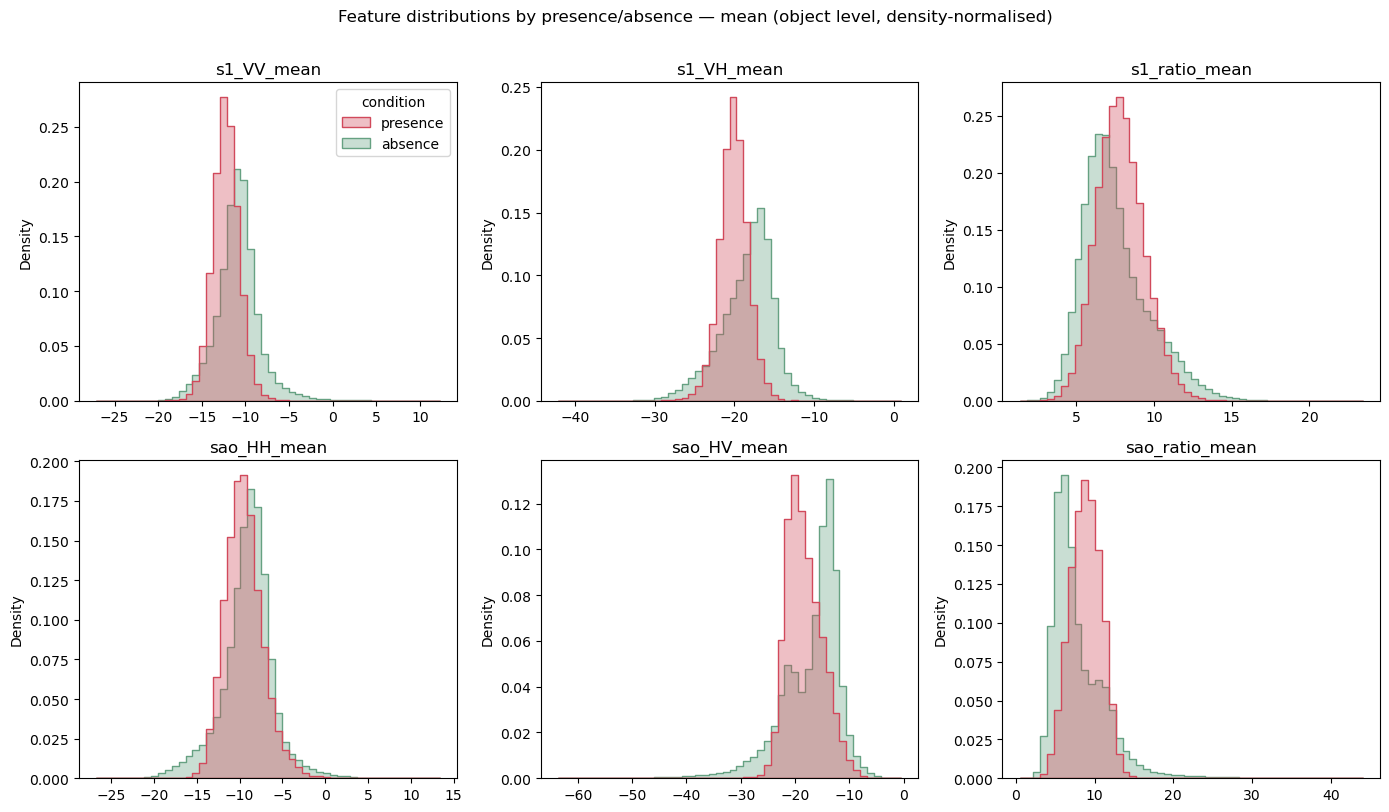

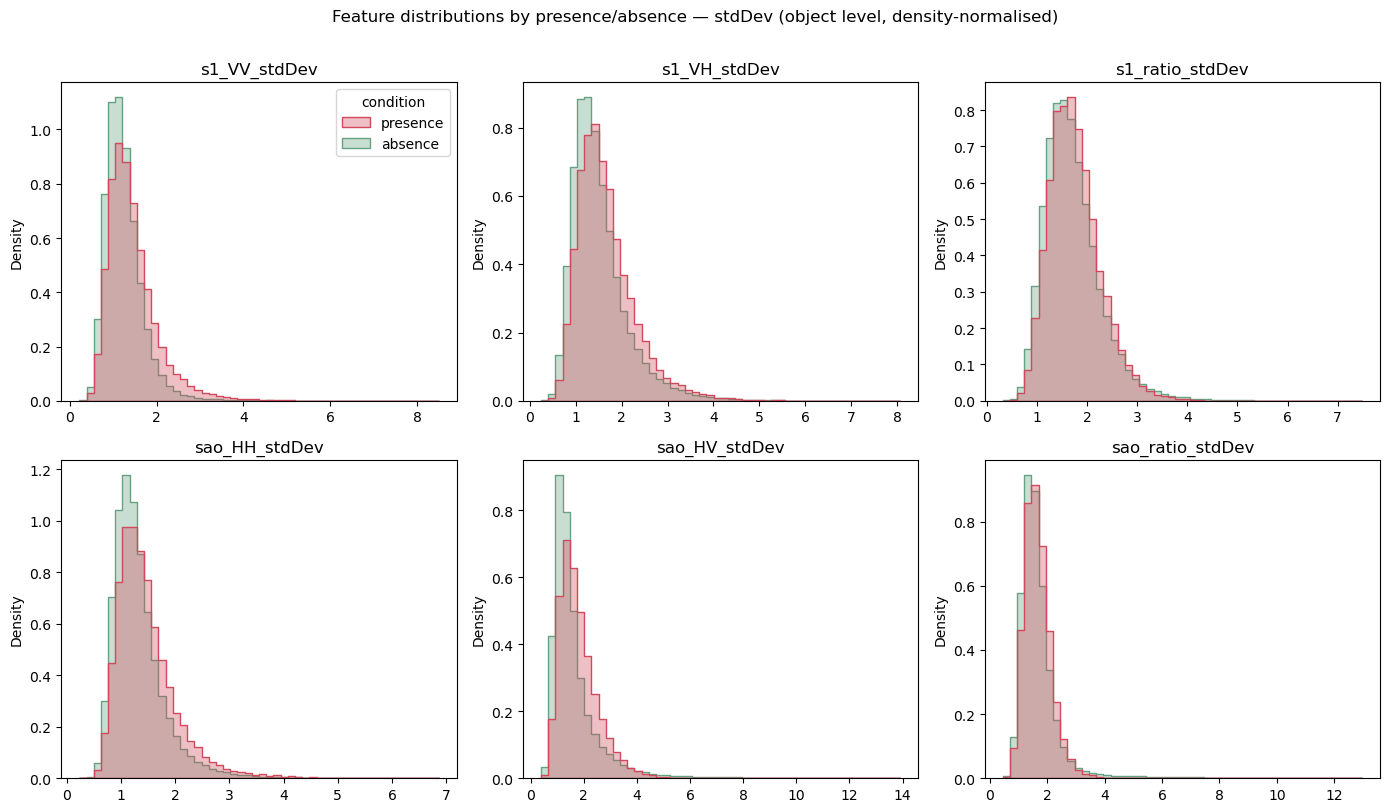

In [ ]:
# Let's have a look to the distribution of our features by class (dam presence / absence).
# We set up the labels and color palette for the plots.
LABELS  = {1: 'presence', 0: 'absence'}
PALETTE = {'presence': '#d1495b', 'absence': '#66a182'}

# Temporary display column just for plotting; the model still uses dam 1/0
plot_df = obj.copy()
plot_df['condition'] = plot_df['dam'].map(LABELS)

# One figure per statistic (mean / stdDev), 6 SAR bands each
for stat in ['mean','stdDev']:
    feats = [f for f in FEATURES_OBJ if f.endswith(f'_{stat}')]
    ncols = 3
    nrows = int(np.ceil(len(feats) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = axes.flatten()

    for i, feat in enumerate(feats):
        sns.histplot(data=plot_df, x=feat, hue='condition',
                     stat='density', common_norm=False,   # normalize each group so shapes are comparable
                     bins=50, element='step', fill=True, alpha=0.35,
                     palette=PALETTE, ax=axes[i], legend=(i == 0))
        axes[i].set_title(feat)
        axes[i].set_xlabel('')

    for j in range(len(feats), len(axes)):   
        axes[j].axis('off')

    fig.suptitle(f'Feature distributions by presence/absence — {stat} (neighbourhood level, density-normalised)', y=1.01)
    fig.tight_layout()
    plt.show()

Similar to the pixel level analysis, the histograms by dam presence and absence at neighbourhood level indicate that none of the individual variables provides a clear distinction between the two classes.

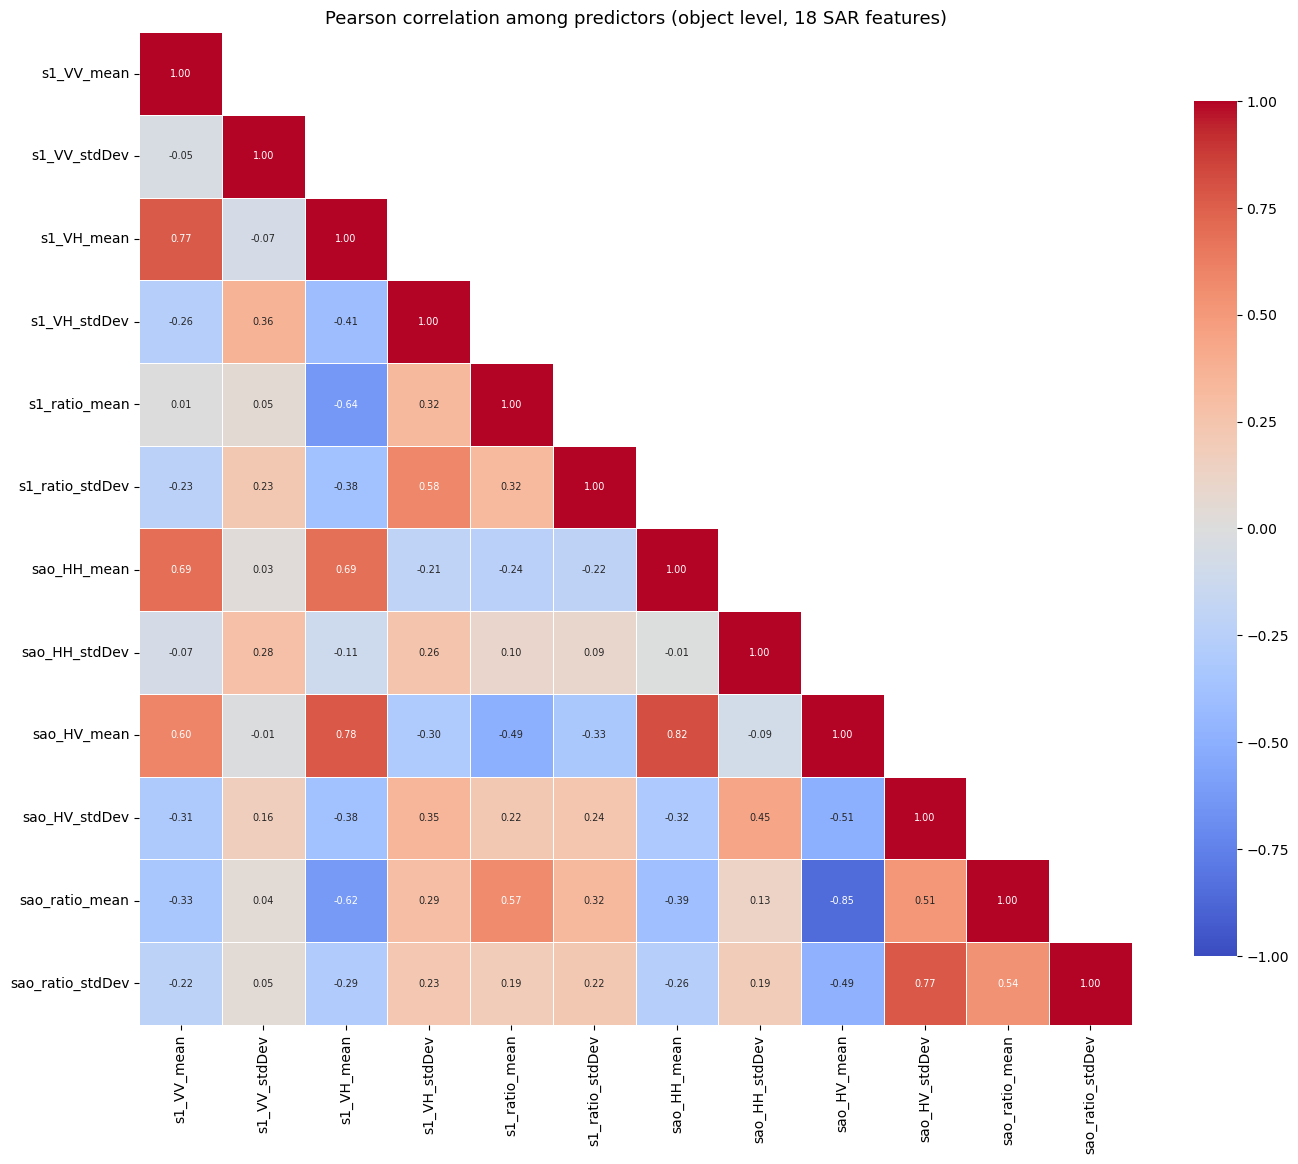

In [ ]:
# Finally, we compute a Pearson correlation matrix across numeric variables to detect potential redundancy.
corr = obj[FEATURES_OBJ].corr(method='pearson')

# Mask the upper triangle 
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

# Plot heatmap 
plt.figure(figsize=(14, 12))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, annot_kws={'size': 7}, cbar_kws={'shrink': 0.8})
plt.title("Pearson correlation among predictors (neighbourhood level, 12 SAR features)", fontsize=13)
plt.tight_layout()
plt.show()

## Variable description

## Variable description (neighbourhood-level analysis)

| Variable | Description | Type | Source | Spatial unit |
|---|---|---|---|---|
| `dam` | Presence (1) or absence (0) of beaver's dam | Binary (1/0) | Huertas Herrera et al (2020) inventory (presence) / random sampling (absence) | 30 m neighbourhood |
| `s1_VV_mean` | Mean Sentinel-1 C-band co-polarised backscatter within the neighbourhood | Numeric (dB) | Sentinel-1 (ESA/Copernicus), 2025 | 30 m neighbourhood |
| `s1_VV_stdDev` | Standard deviation of Sentinel-1 C-band co-polarised backscatter within the neighbourhood | Numeric (dB) | Sentinel-1 (ESA/Copernicus), 2025 | 30 m neighbourhood |
| `s1_VH_mean` | Mean Sentinel-1 C-band cross-polarised backscatter within the neighbourhood | Numeric (dB) | Sentinel-1 (ESA/Copernicus), 2025 | 30 m neighbourhood |
| `s1_VH_stdDev` | Standard deviation of Sentinel-1 C-band cross-polarised backscatter within the neighbourhood | Numeric (dB) | Sentinel-1 (ESA/Copernicus), 2025 | 30 m neighbourhood |
| `s1_ratio_mean` | Mean Sentinel-1 co-/cross-pol ratio (VV − VH) within the neighbourhood | Numeric (dB) | Derived from Sentinel-1 | 30 m neighbourhood |
| `s1_ratio_stdDev` | Standard deviation of Sentinel-1 co-/cross-pol ratio (VV − VH) within the neighbourhood | Numeric (dB) | Derived from Sentinel-1 | 30 m neighbourhood |
| `sao_HH_mean` | Mean SAOCOM L-band co-polarised backscatter within the neighbourhood | Numeric (dB) | SAOCOM (CONAE), 2025 | 30 m neighbourhood |
| `sao_HH_stdDev` | Standard deviation of SAOCOM L-band co-polarised backscatter within the neighbourhood | Numeric (dB) | SAOCOM (CONAE), 2025 | 30 m neighbourhood |
| `sao_HV_mean` | Mean SAOCOM L-band cross-polarised backscatter within the neighbourhood | Numeric (dB) | SAOCOM (CONAE), 2025 | 30 m neighbourhood |
| `sao_HV_stdDev` | Standard deviation of SAOCOM L-band cross-polarised backscatter within the neighbourhood | Numeric (dB) | SAOCOM (CONAE), 2025 | 30 m neighbourhood |
| `sao_ratio_mean` | Mean SAOCOM co-/cross-pol ratio (HH − HV) within the neighbourhood | Numeric (dB) | Derived from SAOCOM | 30 m neighbourhood |
| `sao_ratio_stdDev` | Standard deviation of SAOCOM co-/cross-pol ratio (HH − HV) within the neighbourhood | Numeric (dB) | Derived from SAOCOM | 30 m neighbourhood |

In [12]:
STATS_KEEP = ['mean', 'stdDev']

# SENTINEL-1
FEATURES_S1_OBJ  = [f's1_{b}_{s}'  for b in ['VV','VH','ratio'] for s in STATS_KEEP]
# SAOCOM
FEATURES_SAO_OBJ = [f'sao_{b}_{s}' for b in ['HH','HV','ratio'] for s in STATS_KEEP]

# Combine into the full feature list
FEATURES_OBJ = FEATURES_S1_OBJ + FEATURES_SAO_OBJ   # 12 features

print(f"Object-level features ({len(FEATURES_OBJ)}):", FEATURES_OBJ)

Object-level features (12): ['s1_VV_mean', 's1_VV_stdDev', 's1_VH_mean', 's1_VH_stdDev', 's1_ratio_mean', 's1_ratio_stdDev', 'sao_HH_mean', 'sao_HH_stdDev', 'sao_HV_mean', 'sao_HV_stdDev', 'sao_ratio_mean', 'sao_ratio_stdDev']


In [13]:
# =====================================================================
# 2. METHODOLOGY
# =====================================================================

# We define a reusable helper function used to summarize model performance across the three models.
def summarize_performance(label, y_true, y_pred, y_proba):
    """Key classification metrics for BOTH classes.
    Accuracy is omitted due to the deliberate class balance in training."""
    return {
        'model':         label,
        'recall_dam':    recall_score(y_true, y_pred, pos_label=1),
        'recall_bg':     recall_score(y_true, y_pred, pos_label=0),
        'precision_dam': precision_score(y_true, y_pred, pos_label=1),
        'f1_dam':        f1_score(y_true, y_pred, pos_label=1),
        'kappa':         cohen_kappa_score(y_true, y_pred),
        'roc_auc':       roc_auc_score(y_true, y_proba),
        'pr_auc':        average_precision_score(y_true, y_proba),
    }


In [ ]:
# We run a Moran's I correlogram to measure the spatial autocorrelation of the SAR features.

# We take a random subsample of 5000 pixels.
SUB_N = min(5000, len(obj))
sub = obj.sample(n=SUB_N, random_state=SEED).reset_index(drop=True)
coords = sub[['x', 'y']].values
# use the MEAN features (the level signal); SD is a different dimension
sar_feats_obj = [f for f in FEATURES_OBJ if f.endswith('_mean')]
edges = [0, 250, 500, 750, 1000, 1500, 2000, 2500, 3000, 4000, 5000] # We choose a ring boundaries approach. Each band measures autocorrelation only within a distance ring, excluding nearer neighbours.

print(f"Moran's I ring-based correlogram (neighbourhood level), subsample n={SUB_N}")
header = "ring (m)      | " + " ".join(f"{f.split('_',1)[1]:>10}" for f in sar_feats_obj) + " |  mean"
print(header); print("-" * len(header))

# We run a loop over the specified distance bands to calculate Moran's I for each SAR feature.
for i in range(1, len(edges)):
    d_lo, d_hi = edges[i-1], edges[i]
    w_hi = DistanceBand(coords, threshold=d_hi, binary=True, silence_warnings=True)
    w_ring = w_hi if d_lo == 0 else w_difference(
        w_hi, DistanceBand(coords, threshold=d_lo, binary=True, silence_warnings=True),
        constrained=False, silence_warnings=True)
    w_ring.transform = 'r'
    Is, cells = [], []
    for f in sar_feats_obj:
        try:
            mi = Moran(sub[f].values, w_ring, permutations=99)
            mark = "" if mi.p_sim < 0.05 else "*"
            cells.append(f"{mi.I:+.2f}{mark:>1}"); Is.append(mi.I)
        except Exception:
            cells.append("      n/a")
    mean_I = np.mean(Is) if Is else float('nan')
    print(f"{d_lo:>4}-{d_hi:<5}   | " + " ".join(f"{c:>10}" for c in cells) + f" | {mean_I:+.2f}")

print("\n(* = p >= 0.05, not significant in that ring)")

Moran's I ring-based correlogram (OBJECT level), subsample n=5000
ring (m)      |    VV_mean    VH_mean ratio_mean    HH_mean    HV_mean ratio_mean |  mean
-----------------------------------------------------------------------------------------
   0-250     |     +0.50      +0.51      +0.34      +0.52      +0.61      +0.62  | +0.52
 250-500     |     +0.35      +0.37      +0.22      +0.42      +0.55      +0.52  | +0.41
 500-750     |     +0.24      +0.27      +0.19      +0.25      +0.39      +0.41  | +0.29
 750-1000    |     +0.15      +0.20      +0.12      +0.16      +0.34      +0.36  | +0.22
1000-1500    |     +0.12      +0.17      +0.13      +0.10      +0.28      +0.31  | +0.19
1500-2000    |     +0.10      +0.14      +0.09      +0.08      +0.24      +0.26  | +0.15
2000-2500    |     +0.07      +0.10      +0.07      +0.07      +0.17      +0.19  | +0.11
2500-3000    |     +0.08      +0.10      +0.06      +0.07      +0.17      +0.20  | +0.11
3000-4000    |     +0.07      +0.08      +

The ring-based Moran’s I correlogram indicated strong short-range spatial dependence in the SAR predictors, with the highest autocorrelation occurring within the nearest distance bands. In overall, autocorrelation levels are slightly higher than pixel-level analysis.

In [ ]:
# We set the block size for spatial cross-validation. The block size is set to 2 km, which is the same as the pixel-level analysis.
BLOCK_KM = 2.0   
print(f"\nBLOCK_KM set to {BLOCK_KM} (neighbourhood-level correlogram: elbow ~ 2 - 2.5 km, plateau beyond)")

bs = BLOCK_KM * 1000                              

# We map each neighbourhood's centre coordinate to its grid-cell index.
# Combining the column and row indices gives a unique cell label ("col_row").
# All buffers falling in the same 2x2 km cell share the same block_id, so they
# are always kept together (train OR test)
obj['block_id'] = ((obj['x'] // bs).astype(int).astype(str) + '_' +
                   (obj['y'] // bs).astype(int).astype(str))

# Are there enough blocks (with dams) for a stable k-fold CV?
n_blocks   = obj['block_id'].nunique()                              # total non-empty blocks
dam_blocks = obj.loc[obj['dam'] == 1, 'block_id'].nunique()        # blocks containing >=1 dam
per_block_dams = obj[obj['dam'] == 1].groupby('block_id').size()   # dams per (dam-containing) block

print(f"BLOCK_KM={BLOCK_KM}: {n_blocks} non-empty blocks, {dam_blocks} with >=1 dam")
print(f"dams per block (of those with dams): min={per_block_dams.min()}, "
      f"median={int(per_block_dams.median())}, max={per_block_dams.max()}")



BLOCK_KM set to 2.5 (neighbourhood-level correlogram: elbow ~1.5-2 km, plateau beyond)
BLOCK_KM=2.5: 473 non-empty blocks, 432 with >=1 dam
dams per block (of those with dams): min=1, median=49, max=321


In [ ]:
# We carry a spatial cross-validation. 
# Five folds were then used with GroupKFold, so that all points within a spatial block are assigned to the same fold, preventing any block from being split between training and test. 
N_SPLITS = 5


# We run just the same RF.
def run_rf_spatial(df, features, label, n_splits=N_SPLITS):
    """Block spatial CV on `df`. Pooled out-of-fold metrics + per-fold mean/SD."""
    X = df[features].values
    y = df['dam'].values
    groups = df['block_id'].values

    gkf = GroupKFold(n_splits=n_splits)
    oof_true, oof_pred, oof_proba, per_fold = [], [], [], []

    for tr_idx, te_idx in gkf.split(X, y, groups):
        rf = RandomForestClassifier(n_estimators=500, class_weight='balanced',
                                    random_state=SEED, n_jobs=-1)
        rf.fit(X[tr_idx], y[tr_idx])
        yt, yp = y[te_idx], rf.predict(X[te_idx])
        ypr = rf.predict_proba(X[te_idx])[:, 1]
        oof_true.append(yt); oof_pred.append(yp); oof_proba.append(ypr)
        per_fold.append({'roc_auc': roc_auc_score(yt, ypr),
                         'pr_auc':  average_precision_score(yt, ypr)})

    y_true  = np.concatenate(oof_true)
    y_pred  = np.concatenate(oof_pred)
    y_proba = np.concatenate(oof_proba)
    m = summarize_performance(label, y_true, y_pred, y_proba)

    pf = pd.DataFrame(per_fold)
    m['roc_auc_sd'] = pf['roc_auc'].std()
    m['pr_auc_sd']  = pf['pr_auc'].std()
    return m, (y_true, y_pred, y_proba), pf


In [ ]:
# =====================================================================
# 3. NEIGHBOURHOOD-LEVEL COMPARISON (S1 vs SAOCOM vs both, spatial CV)
# =====================================================================
results_obj = []
m_s1_o,   _, _ = run_rf_spatial(obj, FEATURES_S1_OBJ,  "S1 only (neighbourhood)")
m_sao_o,  _, _ = run_rf_spatial(obj, FEATURES_SAO_OBJ, "SAOCOM only (neighbourhood)")
m_both_o, _, _ = run_rf_spatial(obj, FEATURES_OBJ,     "S1 + SAOCOM (neighbourhood)")
results_obj.extend([m_s1_o, m_sao_o, m_both_o])


cols = ['model', 'roc_auc', 'roc_auc_sd', 'pr_auc', 'pr_auc_sd', 'recall_dam', 'recall_bg']
print("\n=== NEIGHBOURHOOD-LEVEL COMPARISON (2 km spatial block CV) ===")
print(pd.DataFrame(results_obj)[cols].round(3).to_string(index=False))


=== OBJECT-LEVEL COMPARISON (2 km spatial block CV) ===
               model  roc_auc  roc_auc_sd  pr_auc  pr_auc_sd  recall_dam  recall_bg
    S1 only (object)    0.811       0.006   0.474      0.018       0.265      0.939
SAOCOM only (object)    0.808       0.009   0.471      0.011       0.263      0.939
S1 + SAOCOM (object)    0.883       0.006   0.633      0.015       0.448      0.943


In [18]:
# --- Neighbourhood level with MEANS ONLY (6 features) ---
# Isolates the effect of the analysis UNIT (pixel vs neighbourhood) from the effect of
# the extra SD features. run_rf_spatial is already defined above (reused as-is).
F_S1_MEAN  = [f's1_{b}_mean'  for b in ['VV', 'VH', 'ratio']]
F_SAO_MEAN = [f'sao_{b}_mean' for b in ['HH', 'HV', 'ratio']]

results_neigh_mean = []
m_s1_m,   _, _ = run_rf_spatial(obj, F_S1_MEAN,               "S1 only (neighbourhood, mean)")
m_sao_m,  _, _ = run_rf_spatial(obj, F_SAO_MEAN,             "SAOCOM only (neighbourhood, mean)")
m_both_m, _, _ = run_rf_spatial(obj, F_S1_MEAN + F_SAO_MEAN, "S1 + SAOCOM (neighbourhood, mean)")
results_neigh_mean.extend([m_s1_m, m_sao_m, m_both_m])

cols = ['model', 'roc_auc', 'roc_auc_sd', 'pr_auc', 'pr_auc_sd', 'recall_dam', 'recall_bg']
print("=== NEIGHBOURHOOD-LEVEL, MEANS ONLY (6 features, comparable to pixel) ===")
print(pd.DataFrame(results_neigh_mean)[cols].round(3).to_string(index=False))

=== NEIGHBOURHOOD-LEVEL, MEANS ONLY (6 features, comparable to pixel) ===
                            model  roc_auc  roc_auc_sd  pr_auc  pr_auc_sd  recall_dam  recall_bg
    S1 only (neighbourhood, mean)    0.755       0.008   0.392      0.015       0.286      0.903
SAOCOM only (neighbourhood, mean)    0.725       0.005   0.361      0.013       0.245      0.905
S1 + SAOCOM (neighbourhood, mean)    0.849       0.007   0.563      0.018       0.413      0.929


In [19]:
def tss_threshold(y_true, y_proba, thresholds=np.arange(0.05, 0.96, 0.05), label=""):
    rows = []
    for t in thresholds:
        yp = (y_proba >= t).astype(int)
        tp = np.sum((yp==1)&(y_true==1)); fn = np.sum((yp==0)&(y_true==1))
        tn = np.sum((yp==0)&(y_true==0)); fp = np.sum((yp==1)&(y_true==0))
        sens = tp/(tp+fn); spec = tn/(tn+fp)
        rows.append((round(t,2), sens, spec, sens+spec-1))
    tab = pd.DataFrame(rows, columns=['threshold','sensitivity','specificity','TSS'])
    best = tab.loc[tab['TSS'].idxmax()]
    print(f"\n=== TSS sweep: {label} ===")
    print(tab.round(3).to_string(index=False))
    print(f"\nOptimal threshold = {best['threshold']:.2f} (TSS={best['TSS']:.3f}, "
          f"sens={best['sensitivity']:.3f}, spec={best['specificity']:.3f})")
    return float(best['threshold'])

# --- Re-run the combined neighbourhood model capturing OOF predictions ---
m_both_o, pred_both_o, _ = run_rf_spatial(obj, FEATURES_OBJ, "S1 + SAOCOM (neighbourhood)")

y_true_o, _, y_proba_o = pred_both_o
best_t_obj = tss_threshold(y_true_o, y_proba_o, label="S1 + SAOCOM (neighbourhood, spatial CV)")

print("\n=== neighbourhood level: 0.50 vs TSS-optimal ===")
for t in [0.50, best_t_obj]:
    yp = (y_proba_o >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true_o, yp).ravel()
    print(f"threshold={t:.2f} -> recall_dam={tp/(tp+fn):.3f} "
          f"recall_bg={tn/(tn+fp):.3f} precision_dam={tp/(tp+fp):.3f}")


=== TSS sweep: S1 + SAOCOM (neighbourhood, spatial CV) ===
 threshold  sensitivity  specificity   TSS
      0.05        0.977        0.504 0.481
      0.10        0.947        0.619 0.565
      0.15        0.906        0.697 0.604
      0.20        0.862        0.753 0.615
      0.25        0.808        0.800 0.608
      0.30        0.744        0.839 0.583
      0.35        0.675        0.874 0.548
      0.40        0.604        0.900 0.504
      0.45        0.529        0.923 0.453
      0.50        0.451        0.942 0.393
      0.55        0.373        0.957 0.330
      0.60        0.295        0.971 0.266
      0.65        0.220        0.981 0.201
      0.70        0.153        0.988 0.141
      0.75        0.093        0.994 0.087
      0.80        0.046        0.997 0.043
      0.85        0.014        0.999 0.014
      0.90        0.002        1.000 0.002
      0.95        0.000        1.000 0.000

Optimal threshold = 0.20 (TSS=0.615, sens=0.862, spec=0.753)

=== neighbourhood

Finally, the threshold that maximize the TSS is 0.20, slightly higher than the pixel-level analysis, however, its performance is moderate better. At this level, the model detected 86.2% of mapped dam locations while correctly classifying 75.3% of pseudo-absences as negative.